In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rioxarray
import xarray as xr
import dask
import matplotlib.pyplot as plt
import yaml
import os

# User-defined parameters
min_etopo_z = -100
epsg = 4326  # WGS 84
run_config_is2_path = "/Volumes/T7/Duck_SDB/ICESat2/MOD_20250612_132651/classification_outputs/runtime_config.yaml"

# max z for is2 bathy
bathy_range_is2 = (-40, 5)

In [8]:
# Loading data using the run configuration
run_config_is2 = yaml.safe_load(open(run_config_is2_path, 'r'))
# path_to_data = os.path.join(run_config_is2['output_dir'], 'bathymetry.gpkg')
path_to_data = "/Volumes/T7/Duck_SDB/ICESat2/MOD_20250612_132651/classification_outputs/bathymetry.gpkg"
etopo_15s_path = run_config_is2['etopo_15s_path']
name = run_config_is2['request_name']
output_dir = "/Volumes/T7/Duck_SDB/ICESat2/MOD_20250612_132651/classification_outputs"
postprocess_output_path = os.path.join(output_dir, f"IS2_BATHY_{name}.xyz")
gpkg_postprocess_output_path = os.path.join(output_dir, f"IS2_BATHY_{name}.gpkg")

# Read the GeoPackage and create sampling array
gdf = gpd.read_file(path_to_data)
sample_x = gdf.geometry.x
sample_y = gdf.geometry.y
x_sample_points = xr.DataArray(gdf.geometry.x, dims='points')
y_sample_points = xr.DataArray(gdf.geometry.y, dims='points')
extent_is2 = gdf.total_bounds

# Open big ETOPO without reading the data into memory
etopo = rioxarray.open_rasterio(etopo_15s_path, masked=True).squeeze()
etopo = etopo.rio.clip_box(minx=extent_is2[0], miny=extent_is2[1], maxx=extent_is2[2], maxy=extent_is2[3])
etopo_sampled = etopo.sel(x=x_sample_points, y=y_sample_points, method='nearest')
gdf['etopo'] = etopo_sampled.values
gdf = gdf[gdf['etopo'] >= min_etopo_z]

# trim by bathy range for z_ph_refr
gdf = gdf[(gdf['z_ph_refr'] >= bathy_range_is2[0]) & (gdf['z_ph_refr'] <= bathy_range_is2[1])]

# Store the processed data to a new GeoPackage
gdf.to_file(gpkg_postprocess_output_path, driver='GPKG')


In [9]:
# Export as xyz with index, easting, northing, elevation (z_ph_refr)
gdf = gdf.to_crs(gdf.estimate_utm_crs())
gdf.loc[:, 'easting'] = gdf.geometry.x
gdf.loc[:, 'northing'] = gdf.geometry.y
gdf_out = gdf.loc[:, ['easting', 'northing', 'z_ph_refr']].reset_index(drop=True)
gdf_out.columns = ['x', 'y', 'z']
gdf_out.to_csv(postprocess_output_path, sep=' ', index=True, header=None)

In [15]:
gdf_i

,segment_id,rgt,cycle,track,spot,x_ph,z_ph,ref_azimuth,ref_elev,solar_elevation,...,gebco_depth,water_mask,surf_mu,surf_sigma,surf_A,kde_bandwidth,surf_left,surf_right,classification,confidence
120,200626,507,11,2,3,2951.495541,-1.650776,1.488677,1.488856,-6.796219,...,5,True,0.387639,0.336532,1.012527,0.036356,-0.463838,1.090488,3,0.0
121,200627,507,11,2,3,2951.495541,-1.650776,1.488677,1.488856,-6.796062,...,5,True,0.387639,0.336532,1.012527,0.036356,-0.463838,1.090488,3,0.0
134,200627,507,11,2,3,2952.989455,-45.712826,1.488677,1.488856,-6.796062,...,5,True,0.387639,0.336532,1.012527,0.036356,-0.463838,1.090488,3,0.0
135,200626,507,11,2,3,2952.989455,-45.712826,1.488677,1.488856,-6.796219,...,5,True,0.387639,0.336532,1.012527,0.036356,-0.463838,1.090488,3,0.0
138,200627,507,11,2,3,2954.354985,-1.802937,1.488677,1.488856,-6.796062,...,5,True,0.387639,0.336532,1.012527,0.036356,-0.463838,1.090488,3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61960,201370,507,11,2,3,17857.578986,-10.174473,1.488619,1.488845,-6.738168,...,-12,True,0.188675,0.325869,1.043762,0.045064,-0.630461,1.215927,3,0.0
61995,201371,507,11,2,3,17865.371604,-6.589752,1.488618,1.488845,-6.738088,...,-12,True,0.188675,0.325869,1.043762,0.045064,-0.630461,1.215927,3,0.0
61996,201370,507,11,2,3,17865.371604,-6.589752,1.488618,1.488845,-6.738168,...,-12,True,0.188675,0.325869,1.043762,0.045064,-0.630461,1.215927,3,0.0
62005,201371,507,11,2,3,17867.495787,-4.191124,1.488618,1.488845,-6.738088,...,-12,True,0.188675,0.325869,1.043762,0.045064,-0.630461,1.215927,3,0.0


In [72]:
# Manual track filtering
from shapely.geometry import box
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

nearshore = gpd.read_file("/Volumes/T7/Duck_SDB/ICESat2/offshore_zoom.geojson")
extent_nearshore = nearshore.to_crs(nearshore.estimate_utm_crs()).buffer(500).to_crs(nearshore.crs).total_bounds
gdf_viz_extent = gpd.GeoDataFrame(
    geometry=[box(extent_nearshore[0], extent_nearshore[1], extent_nearshore[2], extent_nearshore[3])],
    crs=nearshore.crs
)

has_bathy_dir = "/Volumes/T7/Duck_SDB/ICESat2/MOD_20250612_132651/classification_outputs/debug/has_bathy/best_bathy"
classification_dir = "/Volumes/T7/Duck_SDB/ICESat2/MOD_20250612_132651/classification_outputs"
has_bathy_files = [f for f in os.listdir(has_bathy_dir) if f.endswith('.html') and not f.startswith('._')]

quickview_output_dir = os.path.join(has_bathy_dir, 'quickview') 

gdf_subsurf = []
for filename in has_bathy_files:
    parquet_path = os.path.join(classification_dir, filename.replace('.html', '.parquet'))
    gdf_i = gpd.read_parquet(parquet_path)
    # where classification > 2
    gdf_i = gdf_i[gdf_i['classification'] > 2]

    # clip to nearshore
    gdf_i = gdf_i.clip(nearshore.to_crs(gdf_i.crs))

    if gdf_i.empty:
        print(f"No data for {filename}, skipping...")
        continue

    gdf_subsurf.append(gdf_i)

    gdf_class_5 = gdf_i[gdf_i['classification'] == 5]


    # Create figure with gridspec
    fig = plt.figure(figsize=(16, 9))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])
    
    # Left plot spans full height (overview map)
    ax_map = fig.add_subplot(gs[:, 0])
    
    # Top right plot (without red circles)
    ax_top = fig.add_subplot(gs[0, 1])
    
    # Bottom right plot (with red circles)
    ax_bottom = fig.add_subplot(gs[1, 1])
    
    # Overview map (left side)
    gdf_i.plot(ax=ax_map, color='white', markersize=3, alpha=0.1)

    # if class 5 data exists, add in red to overview map
    if not gdf_class_5.empty:
        gdf_class_5.plot(ax=ax_map, color='red', markersize=3, alpha=0.5, label='Classified bathymetry')
    
    # Add extent box
    gdf_viz_extent.to_crs(gdf_i.crs).plot(ax=ax_map, edgecolor='blue', facecolor='none', linewidth=2)
    
    # Add basemap
    ctx.add_basemap(ax_map, crs=gdf_i.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
    
    ax_map.set_xlabel('Longitude (degrees)')
    ax_map.set_ylabel('Latitude (degrees)')
    ax_map.tick_params(axis='x', rotation=45)
    ax_map.set_title('Overview Map')
    
    # Top right plot - subsurface points only (no red circles)
    ax_top.scatter(gdf_i.geometry.x, gdf_i['z_ph'], s=1, c='black', alpha=0.1, label='Subsurface Points')
    ax_top.set_ylim(-20, 0)
    ax_top.set_xlabel('Longitude (degrees)')
    ax_top.set_ylabel('Uncorrected Elevation (m)')
    ax_top.tick_params(axis='x', rotation=45)
    ax_top.set_title('All Subsurface Photon Returns')
    ax_top.legend()
    
    # Bottom right plot - with red circles (classifications)
    ax_bottom.scatter(gdf_i.geometry.x, gdf_i['z_ph'], s=1, c='black', alpha=0.1, label='Subsurface Points')
    
    # Plot class 5 in red circles
    if not gdf_class_5.empty:
        ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'], 
                         c='red', alpha=0.5, s=10, edgecolors='red', 
                         facecolors='none', linewidth=0.5, label='Classified bathymetry')
    
    ax_bottom.set_ylim(-20, 0)
    ax_bottom.set_xlabel('Longitude (degrees)')
    ax_bottom.set_ylabel('Uncorrected Elevation (m)')
    ax_bottom.tick_params(axis='x', rotation=45)
    ax_bottom.set_title('Subsurface Returns + MOD Bathy Classification')
    ax_bottom.legend()
    
    # Add main title
    fig.suptitle(filename.replace('.html', ''), fontsize=16, y=0.95)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Make room for suptitle

    # Save figure
    quickview_output_path = os.path.join(quickview_output_dir, filename.replace('.html', '.png'))
    os.makedirs(quickview_output_dir, exist_ok=True)
    plt.savefig(quickview_output_path, dpi=300, bbox_inches='tight')
    plt.close()  # Close figure to free memory

/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'],
/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'],
/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'],
/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: Y

No data for 20220626_0065_16_1.html, skipping...
No data for 20220626_0065_16_2.html, skipping...
No data for 20220626_0065_16_3.html, skipping...
No data for 20220626_0065_16_4.html, skipping...
No data for 20220626_0065_16_5.html, skipping...
No data for 20220626_0065_16_6.html, skipping...


/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'],
/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'],
/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax_bottom.scatter(gdf_class_5.geometry.x, gdf_class_5['z_ph'],
/var/folders/14/jdp8yl_s6cj_5ntwcb0cb0k00000gn/T/ipykernel_1822/14356430.py:84: UserWarning: Y

In [23]:
# gdf_subsurf.sample(10000).explore()

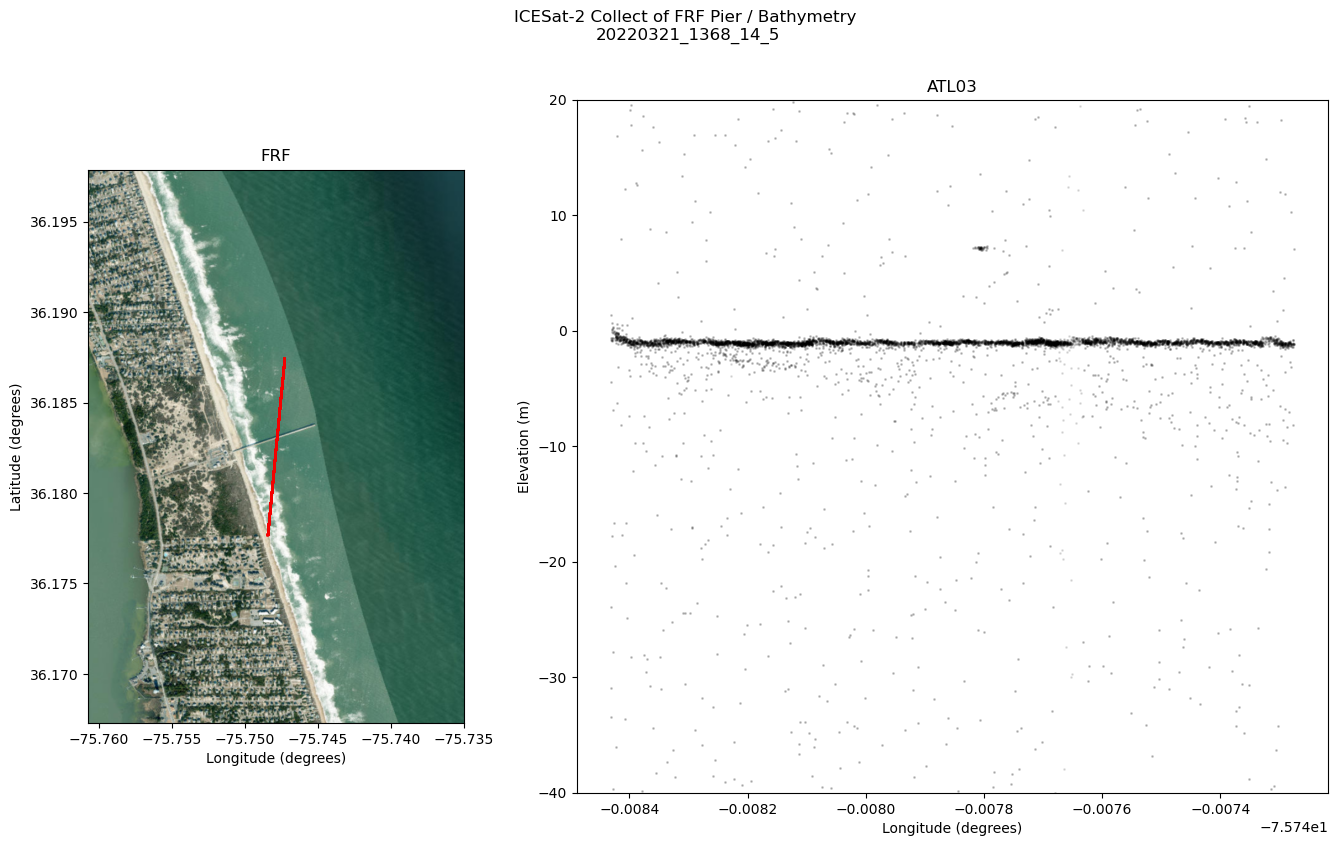

In [96]:
# pier plot
pier_name = "20220321_1368_14_5.parquet"
pier_gdf = gpd.read_parquet(os.path.join(classification_dir, pier_name))

# x_ph filter between 7500 and 9500
pier_gdf = pier_gdf[(pier_gdf['x_ph'] >= 8800) & (pier_gdf['x_ph'] <= 10000)]

# plot x_ph vs z_ph
fig, ax = plt.subplots(1, 2, figsize=(16, 9), width_ratios=[1, 2])
ax[1].scatter(x=pier_gdf.geometry.x, y=pier_gdf['z_ph'], s=1, alpha=0.1, color='black')
ax[1].set_xlabel('Longitude (degrees)')
ax[1].set_ylabel('Elevation (m)')
ax[1].set_ylim(-40, 20)
ax[1].set_title(f"ATL03")


# add geometry context on left
pier_gdf.geometry.plot(ax=ax[0], color='red', markersize=1, alpha=0.1)
pier_extent = pier_gdf.to_crs(pier_gdf.estimate_utm_crs()).buffer(1000).to_crs(pier_gdf.crs).total_bounds
pier_viz_extent = gpd.GeoDataFrame(
    geometry=[box(pier_extent[0], pier_extent[1], pier_extent[2], pier_extent[3])],
    crs=pier_gdf.crs
)
ax[0].set_title('FRF')
ax[0].set_xlabel('Longitude (degrees)')
ax[0].set_ylabel('Latitude (degrees)')

plt.suptitle(f"ICESat-2 Collect of FRF Pier / Bathymetry \n{pier_name.split('.')[0]}")
pier_viz_extent.to_crs(pier_gdf.crs).plot(ax=ax[0], edgecolor='none', facecolor='none', linewidth=2)
ctx.add_basemap(ax[0], crs=pier_gdf.crs, source=ctx.providers.Esri.WorldImagery, attribution=False)
